# Versao 12 - Classificacao Multiclasse Com LSTM Profunda Hierarquica Multitarefa

Este e o notebook central da `versao12`. Aqui treinamos a arquitetura que combina profundidade alta, separacao de ramos, hierarquia temporal, `X_tab`, mascaras operacionais, embedding de contexto e multitarefa.

## Hipotese experimental imediata

Se a leitura metodologica das versoes anteriores estiver correta, a `versao12` deve ser capaz de unir:

- a expressividade da `versao7`;
- a organizacao temporal da `versao9`;
- a fidelidade estrutural da `versao10`;
- a limpeza de entrada da `versao11`.

O objetivo deste notebook e medir se essa sintese vira ganho real de classificacao.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao12" else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import versao12.pipeline_v12 as pipeline_v12

pipeline_v12 = importlib.reload(pipeline_v12)
DeepHierarchicalMultitaskTemporalModel = pipeline_v12.DeepHierarchicalMultitaskTemporalModel
evaluate_predictions = pipeline_v12.evaluate_predictions
export_evaluation_artifacts = pipeline_v12.export_evaluation_artifacts
load_bundle = pipeline_v12.load_bundle
load_multitask_temporal_model = pipeline_v12.load_multitask_temporal_model
load_split_arrays = pipeline_v12.load_split_arrays
plot_confusion_matrix_for_predictions = pipeline_v12.plot_confusion_matrix_for_predictions
predict_multitask_model_classes = pipeline_v12.predict_multitask_model_classes
prepare_classification_artifacts = pipeline_v12.prepare_classification_artifacts
resolve_feature_group_indices = pipeline_v12.resolve_feature_group_indices
train_multitask_temporal_model = pipeline_v12.train_multitask_temporal_model

RUN_NAME = "classificacao_v12_profunda_hierarquica_multitarefa"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v12" / RUN_NAME
LSTM_DIR = RUN_DIR / "lstm"
DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"

if not (RUN_DIR / "bundle_v12.json").exists():
    prepare_classification_artifacts(
        dataset_root=DATASET_ROOT,
        run_name=RUN_NAME,
        random_state=42,
        sequence_length=180,
    )


In [2]:
bundle = load_bundle(RUN_DIR / "bundle_v12.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
validation_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

continuous_indices, state_indices = resolve_feature_group_indices(
    bundle.selected_columns,
    bundle.state_columns,
)

model = DeepHierarchicalMultitaskTemporalModel(
    input_size=train_arrays["X_seq"].shape[-1],
    tabular_size=train_arrays["X_tab"].shape[-1],
    num_classes=len(bundle.class_labels),
    num_step_classes=len(bundle.observation_class_codes),
    num_state_classes=len(bundle.observation_state_codes),
    source_vocab_size=len(bundle.source_mapping),
    continuous_indices=continuous_indices,
    state_indices=state_indices,
    window_size=20,
    continuous_hidden_size=128,
    state_hidden_size=96,
    local_num_layers=2,
    branch_projection_size=160,
    context_hidden_size=192,
    context_num_layers=3,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.30,
)

model


DeepHierarchicalMultitaskTemporalModel(
  (sequence_input_norm): LayerNorm((18,), eps=1e-05, elementwise_affine=True)
  (source_embedding): Embedding(3, 12)
  (branch_modules): ModuleDict(
    (continuous): ModuleDict(
      (input_norm): LayerNorm((27,), eps=1e-05, elementwise_affine=True)
      (encoder): LSTM(27, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
      (output_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): Linear(in_features=256, out_features=1, bias=True)
      (projection): Sequential(
        (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=768, out_features=160, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.3, inplace=False)
      )
    )
    (state): ModuleDict(
      (input_norm): LayerNorm((27,), eps=1e-05, elementwise_affine=True)
      (encoder): LSTM(27, 96, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
      (output_

In [3]:
training_summary = train_multitask_temporal_model(
    X_train_seq=train_arrays["X_seq"],
    X_train_tab=train_arrays["X_tab"],
    X_train_missing=train_arrays["X_missing"],
    X_train_frozen=train_arrays["X_frozen"],
    y_train=train_arrays["y"],
    y_train_step_class=train_arrays["y_step_class"],
    y_train_step_state=train_arrays["y_step_state"],
    train_source_id=train_arrays["source_id"],
    X_val_seq=validation_arrays["X_seq"],
    X_val_tab=validation_arrays["X_tab"],
    X_val_missing=validation_arrays["X_missing"],
    X_val_frozen=validation_arrays["X_frozen"],
    y_val=validation_arrays["y"],
    y_val_step_class=validation_arrays["y_step_class"],
    y_val_step_state=validation_arrays["y_step_state"],
    val_source_id=validation_arrays["source_id"],
    output_dir=LSTM_DIR,
    class_labels=bundle.class_labels,
    observation_class_codes=bundle.observation_class_codes,
    observation_state_codes=bundle.observation_state_codes,
    source_vocab_size=len(bundle.source_mapping),
    feature_columns=bundle.selected_columns,
    state_columns=bundle.state_columns,
    window_size=20,
    continuous_hidden_size=128,
    state_hidden_size=96,
    local_num_layers=2,
    branch_projection_size=160,
    context_hidden_size=192,
    context_num_layers=3,
    source_embedding_dim=12,
    tabular_hidden_size=160,
    dropout=0.30,
    learning_rate=4e-4,
    weight_decay=1e-4,
    batch_size=48,
    epochs=65,
    patience=12,
    lambda_step_class=0.35,
    lambda_step_state=0.15,
    random_state=42,
)

training_summary


MultiTaskTrainingSummary(model_name='deep_hierarchical_multitask_temporal_model', checkpoint_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/hierarchical_multitask_temporal_best.pt', config_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/hierarchical_multitask_temporal_config.json', history_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v12/classificacao_v12_profunda_hierarquica_multitarefa/lstm/hierarchical_multitask_temporal_history.csv', best_epoch=12, best_val_macro_f1=0.9576017957229466, best_val_accuracy=0.9580838323353293, best_val_balanced_accuracy=0.9625437398222196)

In [4]:
best_model = load_multitask_temporal_model(training_summary.config_path)

validation_pred = predict_multitask_model_classes(
    best_model,
    validation_arrays["X_seq"],
    validation_arrays["X_tab"],
    validation_arrays["X_missing"],
    validation_arrays["X_frozen"],
    validation_arrays["source_id"],
)
test_pred = predict_multitask_model_classes(
    best_model,
    test_arrays["X_seq"],
    test_arrays["X_tab"],
    test_arrays["X_missing"],
    test_arrays["X_frozen"],
    test_arrays["source_id"],
)

validation_eval = evaluate_predictions(
    validation_arrays["y"],
    validation_pred,
    class_labels=bundle.class_labels,
)
test_eval = evaluate_predictions(
    test_arrays["y"],
    test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(validation_eval, LSTM_DIR, "multitask_validation")
export_evaluation_artifacts(test_eval, LSTM_DIR, "multitask_test")

pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": validation_eval["accuracy"],
            "macro_f1": validation_eval["macro_f1"],
            "balanced_accuracy": validation_eval["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "balanced_accuracy": test_eval["balanced_accuracy"],
        },
    ]
)


,split,accuracy,macro_f1,balanced_accuracy
0,validation,0.958084,0.957602,0.962544
1,test,0.943284,0.929828,0.956111


,epoch,learning_rate,train_loss,train_instance_loss,train_step_class_loss,train_step_state_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_accuracy,val_macro_f1,val_balanced_accuracy
19,20,0.0002,0.139161,0.046990,0.144593,0.277092,0.958307,0.956433,0.973079,0.940120,0.934675,0.945918
20,21,0.0002,0.124903,0.040397,0.136789,0.244199,0.964721,0.963001,0.973931,0.958084,0.949784,0.957786
21,22,0.0002,0.119192,0.037277,0.135820,0.229189,0.946761,0.952878,0.968809,0.928144,0.928052,0.942364
22,23,0.0002,0.108114,0.032734,0.129911,0.199407,0.962797,0.963747,0.977769,0.934132,0.928334,0.947123
23,24,0.0002,0.131942,0.039364,0.143472,0.282419,0.958948,0.961285,0.971718,0.934132,0.927271,0.936576


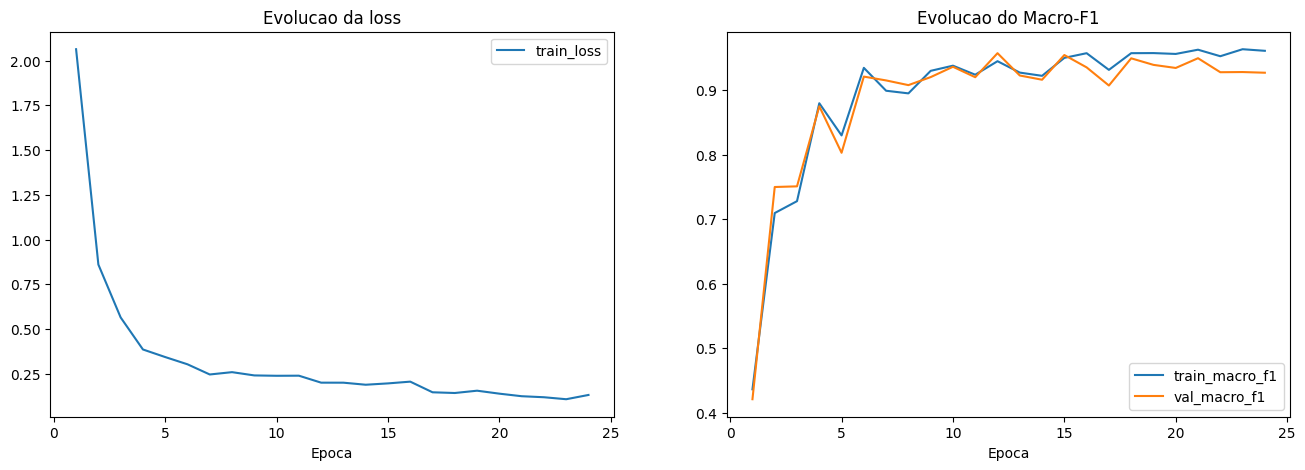

In [5]:
history = pd.read_csv(training_summary.history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history["epoch"], history["train_loss"], label="train_loss")
axes[0].set_title("Evolucao da loss")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_macro_f1"], label="train_macro_f1")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("Evolucao do Macro-F1")
axes[1].set_xlabel("Epoca")
axes[1].legend()
plt.show()


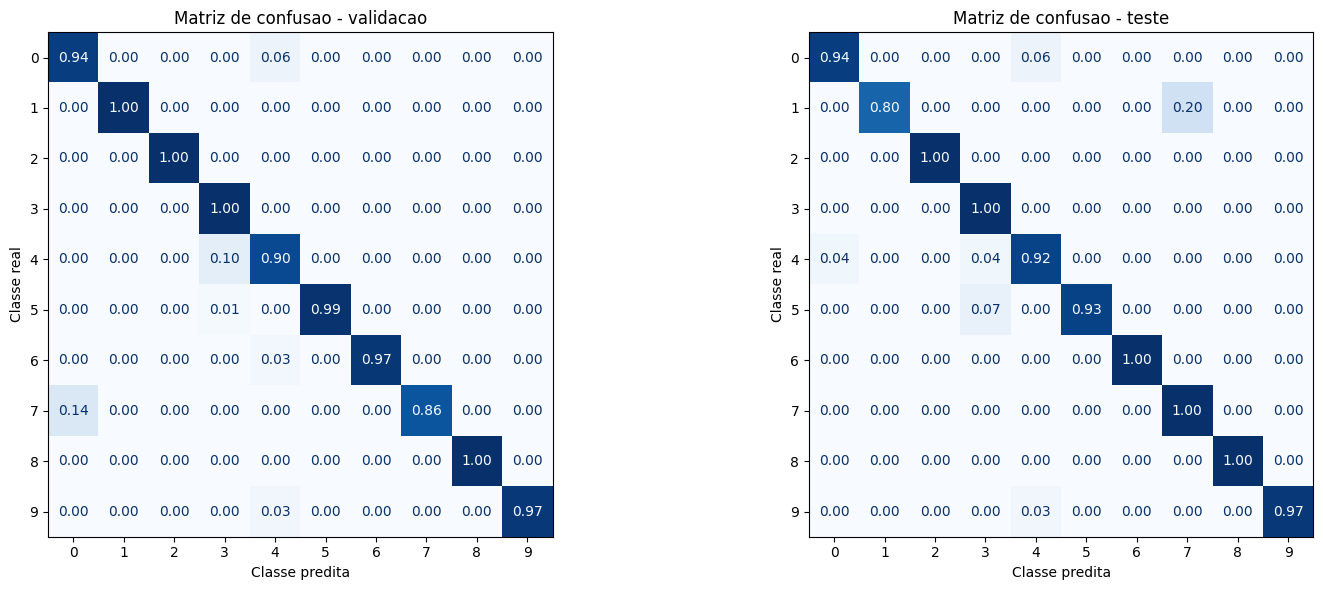

,label,precision,recall,f1-score,support
0,0,0.976744,0.943820,0.960000,89.000000
1,1,1.000000,0.800000,0.888889,20.000000
2,2,1.000000,1.000000,1.000000,5.000000
3,3,0.695652,1.000000,0.820513,16.000000
4,4,0.888889,0.923077,0.905660,52.000000
5,5,1.000000,0.926471,0.961832,68.000000
6,6,1.000000,1.000000,1.000000,33.000000
7,7,0.636364,1.000000,0.777778,7.000000
8,8,1.000000,1.000000,1.000000,14.000000
9,9,1.000000,0.967742,0.983607,31.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix_for_predictions(
    validation_arrays["y"],
    validation_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - validacao",
    ax=axes[0],
)
plot_confusion_matrix_for_predictions(
    test_arrays["y"],
    test_pred,
    bundle.class_labels,
    normalize="true",
    title="Matriz de confusao - teste",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

display(test_eval["classification_report_df"])


## Leitura final

Se a `versao12` superar a `versao10`, isso sera um sinal forte de que a sintese arquitetural valeu a pena. Se ela nao superar, o resultado continua importante: mostrara com mais clareza quais blocos realmente agregam valor quando colocados juntos e quais apenas aumentam complexidade.